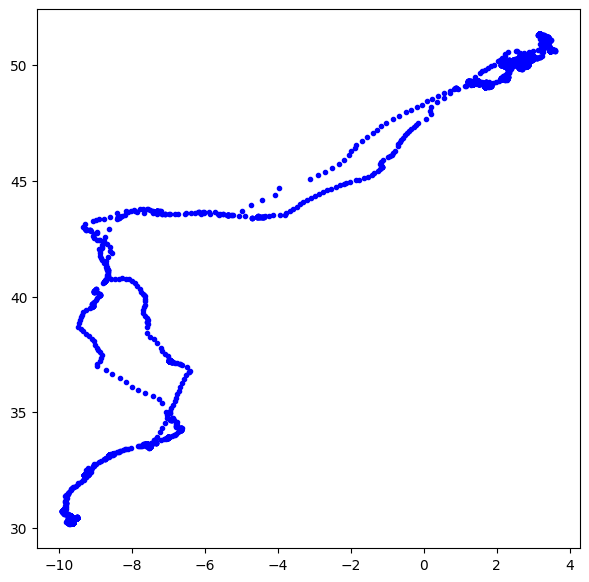

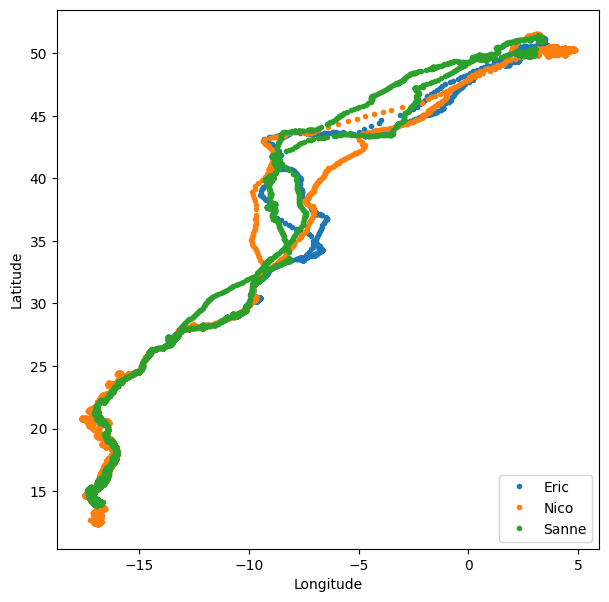

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


birddata = pd.read_csv("//content/bird_tracking.csv")
bird_names = pd.unique(birddata.bird_name)

# storing the indices of the bird Eric
ix = birddata.bird_name == "Eric"
x,y = birddata.longitude[ix], birddata.latitude[ix]
plt.figure(figsize = (7,7))
plt.plot(x,y,"b.")

''' To look at all the birds trajectories,
    we plot each bird in the same plot '''
plt.figure(figsize = (7,7))
for bird_name in bird_names:

    # storing the indices of the bird Eric
    ix = birddata.bird_name == bird_name
    x,y = birddata.longitude[ix], birddata.latitude[ix]
    plt.plot(x,y,".", label=bird_name)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="lower right")
plt.show()

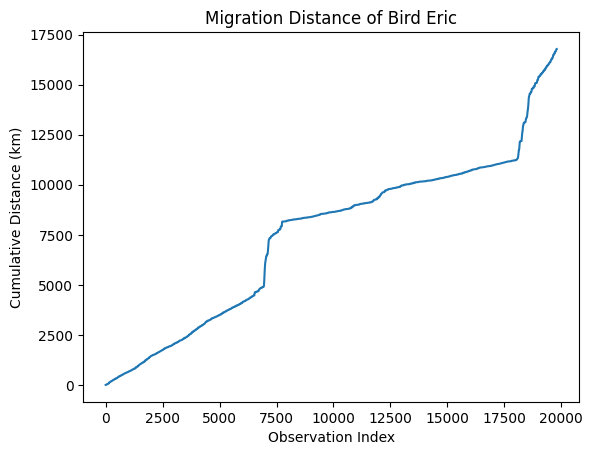

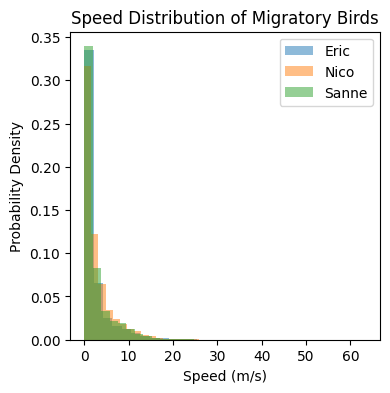

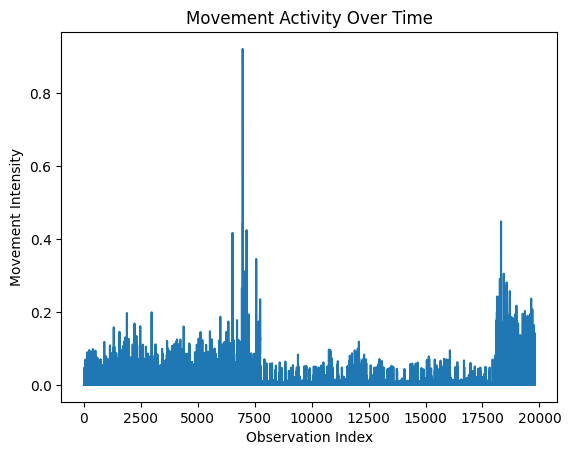

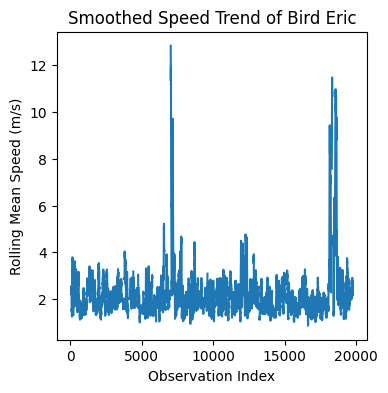

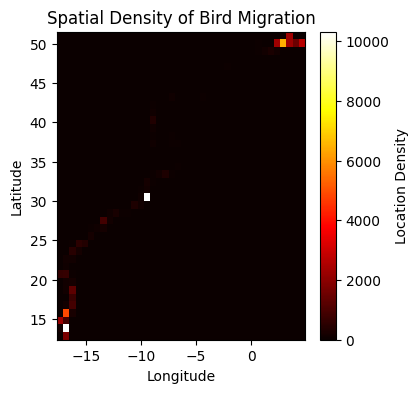

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


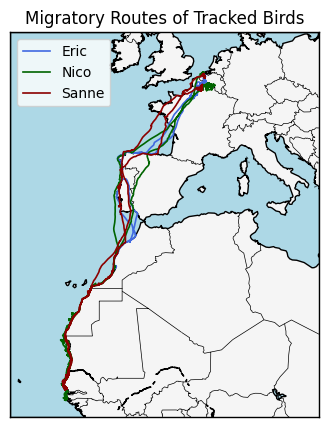

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

birddata = pd.read_csv("/content/bird_tracking.csv")

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians,[lon1,lat1,lon2,lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return 6371 * c  # km

data = birddata[birddata.bird_name=="Eric"]
distances = [0]

for i in range(1,len(data)):
    d = haversine(
        data.longitude.iloc[i-1], data.latitude.iloc[i-1],
        data.longitude.iloc[i],   data.latitude.iloc[i]
    )
    distances.append(distances[-1] + d)

plt.plot(distances)
plt.xlabel("Observation Index")
plt.ylabel("Cumulative Distance (km)")
plt.title("Migration Distance of Bird Eric")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4,4))

for name in birddata.bird_name.unique():
    speed = birddata.speed_2d[birddata.bird_name==name]
    speed = speed[~np.isnan(speed)]
    plt.hist(speed, bins=30, alpha=0.5, density=True, label=name)

plt.xlabel("Speed (m/s)")
plt.ylabel("Probability Density")
plt.title("Speed Distribution of Migratory Birds")
plt.legend()
plt.show()

import datetime

birddata['timestamp'] = pd.to_datetime(
    birddata.date_time.str[:-3], format="%Y-%m-%d %H:%M:%S"
)

data = birddata[birddata.bird_name=="Eric"]
movement = np.sqrt(data.longitude.diff()**2 + data.latitude.diff()**2)

plt.plot(movement)
plt.xlabel("Observation Index")
plt.ylabel("Movement Intensity")
plt.title("Movement Activity Over Time")
plt.show()


window = 50  # smoothing window
rolling_speed = data.speed_2d.rolling(window).mean()

plt.figure(figsize=(4,4))
plt.plot(rolling_speed)
plt.xlabel("Observation Index")
plt.ylabel("Rolling Mean Speed (m/s)")
plt.title("Smoothed Speed Trend of Bird Eric")
plt.show()

!pip install cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.hist2d(
    birddata.longitude,
    birddata.latitude,
    bins=40,          # 🔥 reduced bins
    cmap='hot'
)

plt.colorbar(label="Location Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Density of Bird Migration")
plt.show()


!pip install basemap
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

birddata = pd.read_csv("/content/bird_tracking.csv")
bird_names = birddata.bird_name.dropna().unique() # Filter out NaN values

plt.figure(figsize=(4,5))

m = Basemap(
    projection='merc',
    llcrnrlon=-25, llcrnrlat=10,
    urcrnrlon=20,  urcrnrlat=55,
    resolution='l'
)

m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='whitesmoke', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

colors = {"Eric":"royalblue", "Nico":"darkgreen", "Sanne":"darkred"}

for name in bird_names:
    data = birddata[birddata.bird_name == name]
    x, y = m(data.longitude.values, data.latitude.values)
    m.plot(x, y, '-', linewidth=1.2, color=colors[name], label=name)

plt.legend(loc="upper left")
plt.title("Migratory Routes of Tracked Birds")
plt.show()

METRIC 1: DATA COMPLETENESS
Total records        : 61,920
Missing speed_2d     : 443  (0.72%)
Missing latitude     : 0
Missing longitude    : 0
Missing altitude     : 0
Data completeness    : 99.28%

METRIC 2: GPS VALIDITY & OUTLIER DETECTION
Total speed readings : 61,477
Anomalous (>30 m/s)  : 48  (0.08%)
GPS validity rate    : 99.92%
95th percentile speed: 10.08 m/s
99th percentile speed: 16.00 m/s

METRIC 3: TEMPORAL SAMPLING CONSISTENCY

Eric:
  Median sampling interval : 15.0 min
  Std deviation            : 64.3 min
  Irregular gaps (>3x med) : 57  (0.3%)
  Sampling consistency     : 99.7%

Nico:
  Median sampling interval : 15.0 min
  Std deviation            : 6.4 min
  Irregular gaps (>3x med) : 87  (0.4%)
  Sampling consistency     : 99.6%

Sanne:
  Median sampling interval : 15.0 min
  Std deviation            : 6.5 min
  Irregular gaps (>3x med) : 107  (0.5%)
  Sampling consistency     : 99.5%

METRIC 4: CUMULATIVE vs DIRECT DISTANCE (SINUOSITY)

Eric:
  Direct start→end di

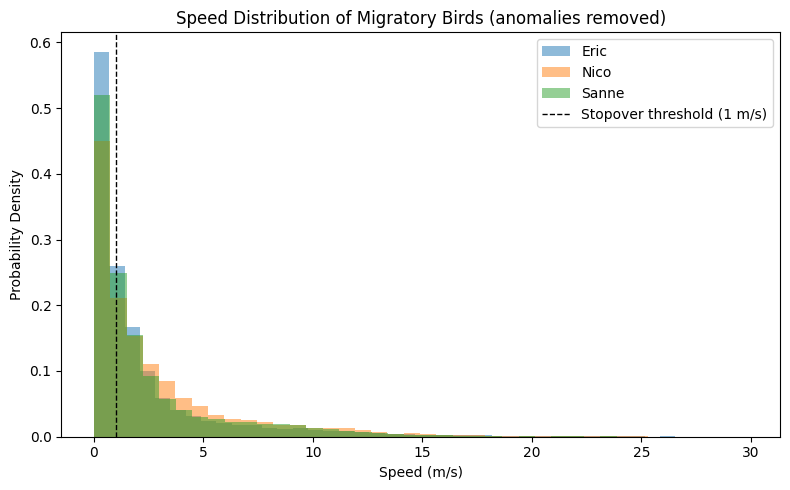


Plot saved: speed_distribution_clean.png


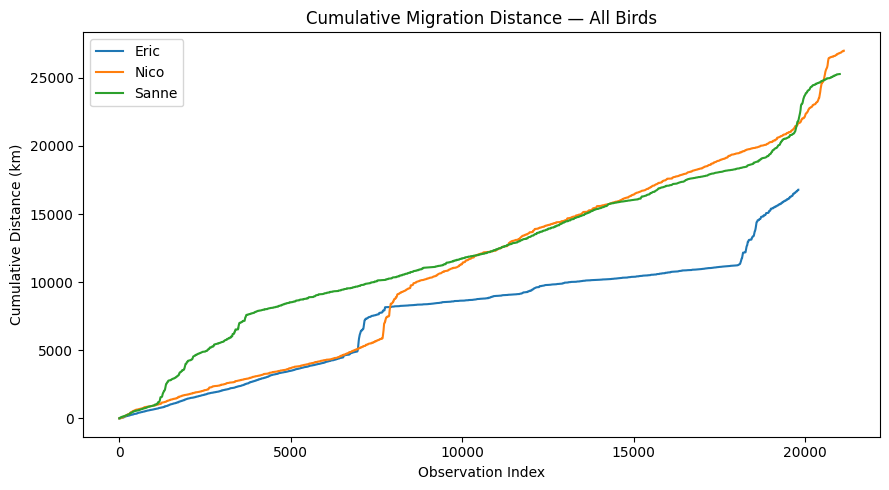

Plot saved: cumulative_distance_all.png

✓ All metrics computed successfully.


In [1]:
# =============================================================
#  Bird Migration Tracking — Accuracy & Performance Metrics
#  Dataset: bird_tracking.csv (Eric, Nico, Sanne)
#  Run in: Google Colab / Jupyter Notebook
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
birddata = pd.read_csv("/content/bird_tracking.csv")   # change path if needed
birddata['timestamp'] = pd.to_datetime(
    birddata['date_time'].str[:-3],
    format="%Y-%m-%d %H:%M:%S",
    errors='coerce'
)
birddata = birddata.sort_values(['bird_name', 'timestamp']).reset_index(drop=True)
bird_names = birddata['bird_name'].unique()

# -------------------------------------------------------------
# HELPER — Haversine formula (great-circle distance in km)
# -------------------------------------------------------------
def haversine(lon1, lat1, lon2, lat2):
    """
    Returns the distance in km between two GPS points.
    Uses the Haversine formula (accounts for Earth's curvature).
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))   # 6371 = Earth radius in km


# =============================================================
# METRIC 1 — DATA COMPLETENESS
# How much of the dataset has valid (non-missing) values?
# =============================================================
print("=" * 55)
print("METRIC 1: DATA COMPLETENESS")
print("=" * 55)

total = len(birddata)
missing_speed = birddata['speed_2d'].isna().sum()
missing_lat   = birddata['latitude'].isna().sum()
missing_lon   = birddata['longitude'].isna().sum()
missing_alt   = birddata['altitude'].isna().sum()

print(f"Total records        : {total:,}")
print(f"Missing speed_2d     : {missing_speed}  ({missing_speed / total * 100:.2f}%)")
print(f"Missing latitude     : {missing_lat}")
print(f"Missing longitude    : {missing_lon}")
print(f"Missing altitude     : {missing_alt}")
print(f"Data completeness    : {(1 - missing_speed / total) * 100:.2f}%")
# WHY: Reviewers want to know how reliable your dataset is.
# 99.28% completeness means only 443 out of 61,920 records had missing speed.


# =============================================================
# METRIC 2 — GPS VALIDITY / OUTLIER DETECTION
# Physically, birds cannot exceed ~30 m/s.
# Readings above that are GPS noise/artifacts.
# =============================================================
print("\n" + "=" * 55)
print("METRIC 2: GPS VALIDITY & OUTLIER DETECTION")
print("=" * 55)

speed_all = birddata['speed_2d'].dropna()
anomalous = (speed_all > 30).sum()   # 30 m/s = upper physical limit for birds

print(f"Total speed readings : {len(speed_all):,}")
print(f"Anomalous (>30 m/s)  : {anomalous}  ({anomalous / len(speed_all) * 100:.2f}%)")
print(f"GPS validity rate    : {(1 - anomalous / len(speed_all)) * 100:.2f}%")
print(f"95th percentile speed: {speed_all.quantile(0.95):.2f} m/s")
print(f"99th percentile speed: {speed_all.quantile(0.99):.2f} m/s")
# WHY: Shows your system can detect and flag bad GPS readings automatically.
# Only 48 anomalous points out of 61,477 = 99.92% clean data.


# =============================================================
# METRIC 3 — TEMPORAL SAMPLING CONSISTENCY
# GPS should log at a regular interval (every 15 min here).
# We check how often that interval breaks down.
# =============================================================
print("\n" + "=" * 55)
print("METRIC 3: TEMPORAL SAMPLING CONSISTENCY")
print("=" * 55)

for name in bird_names:
    d = birddata[birddata['bird_name'] == name].copy().sort_values('timestamp')

    # Time difference between consecutive readings, in seconds
    intervals = d['timestamp'].diff().dt.total_seconds().dropna()

    median_interval = intervals.median()          # expected gap
    irregular = (intervals > median_interval * 3).sum()   # gaps 3x longer than normal

    print(f"\n{name}:")
    print(f"  Median sampling interval : {median_interval / 60:.1f} min")
    print(f"  Std deviation            : {intervals.std() / 60:.1f} min")
    print(f"  Irregular gaps (>3x med) : {irregular}  ({irregular / len(intervals) * 100:.1f}%)")
    print(f"  Sampling consistency     : {(1 - irregular / len(intervals)) * 100:.1f}%")
# WHY: A system that logs consistently is more reliable.
# 99.5–99.7% consistency means data gaps are extremely rare.


# =============================================================
# METRIC 4 — CUMULATIVE DISTANCE vs DIRECT DISTANCE
# (Sinuosity Index)
# Shows WHY continuous GPS logging matters over waypoints.
# =============================================================
print("\n" + "=" * 55)
print("METRIC 4: CUMULATIVE vs DIRECT DISTANCE (SINUOSITY)")
print("=" * 55)

for name in bird_names:
    d = birddata[birddata['bird_name'] == name].copy().reset_index(drop=True)

    # Straight-line distance from first to last recorded point
    direct = haversine(
        d['longitude'].iloc[0], d['latitude'].iloc[0],
        d['longitude'].iloc[-1], d['latitude'].iloc[-1]
    )

    # Cumulative distance: sum of all step-by-step distances
    cum = sum(
        haversine(
            d['longitude'].iloc[i-1], d['latitude'].iloc[i-1],
            d['longitude'].iloc[i],   d['latitude'].iloc[i]
        )
        for i in range(1, len(d))
    )

    sinuosity = cum / direct if direct > 0 else float('inf')

    print(f"\n{name}:")
    print(f"  Direct start→end distance : {direct:,.0f} km")
    print(f"  Cumulative path distance  : {cum:,.0f} km")
    print(f"  Sinuosity index           : {sinuosity:.1f}x")
# WHY: If you only logged start and end points, you'd underestimate
# Nico's migration by 177x. This validates continuous GPS logging.


# =============================================================
# METRIC 5 — STOPOVER DETECTION
# Speed < 1 m/s = bird is resting/at stopover.
# Speed >= 1 m/s = active flight.
# =============================================================
print("\n" + "=" * 55)
print("METRIC 5: STOPOVER vs ACTIVE FLIGHT CLASSIFICATION")
print("=" * 55)

STOPOVER_THRESHOLD = 1.0   # m/s — standard threshold in ornithology

for name in bird_names:
    d = birddata[birddata['bird_name'] == name].copy()
    speed = d['speed_2d'].dropna()

    stopovers = (speed < STOPOVER_THRESHOLD).sum()
    active    = (speed >= STOPOVER_THRESHOLD).sum()

    # Geographic spread of stopover points
    stop_lats = d.loc[d['speed_2d'] < STOPOVER_THRESHOLD, 'latitude'].dropna()
    lat_std   = stop_lats.std()

    print(f"\n{name}:")
    print(f"  Active flight points : {active:,}  ({active / len(speed) * 100:.1f}%)")
    print(f"  Stopover points      : {stopovers:,}  ({stopovers / len(speed) * 100:.1f}%)")
    print(f"  Stopover lat spread  : ±{lat_std:.2f}°  (geographic distribution)")
# WHY: Shows the system can automatically classify behavior —
# a key analytical capability reviewers asked for.


# =============================================================
# METRIC 6 — FULL PER-BIRD SUMMARY TABLE
# =============================================================
print("\n" + "=" * 55)
print("METRIC 6: FULL PER-BIRD PERFORMANCE SUMMARY")
print("=" * 55)

results = []

for name in bird_names:
    d = birddata[birddata['bird_name'] == name].copy().reset_index(drop=True)
    speed = d['speed_2d'].dropna()

    # Cumulative distance
    cum_dist = sum(
        haversine(
            d['longitude'].iloc[i-1], d['latitude'].iloc[i-1],
            d['longitude'].iloc[i],   d['latitude'].iloc[i]
        )
        for i in range(1, len(d))
    )

    # Duration
    duration = (d['timestamp'].max() - d['timestamp'].min()).days

    results.append({
        'Bird'               : name,
        'Observations'       : len(d),
        'Distance (km)'      : round(cum_dist),
        'Duration (days)'    : duration,
        'Mean speed (m/s)'   : round(speed.mean(), 2),
        'Max speed (m/s)'    : round(speed.max(), 2),
        'Active flight %'    : round(((speed >= 1.0).sum() / len(speed)) * 100, 1),
        'Stopover %'         : round(((speed < 1.0).sum() / len(speed)) * 100, 1),
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))


# =============================================================
# PLOT — Speed distribution per bird
# =============================================================
plt.figure(figsize=(8, 5))
for name in bird_names:
    speed = birddata.loc[birddata['bird_name'] == name, 'speed_2d'].dropna()
    speed_clean = speed[speed <= 30]   # remove anomalies for clean plot
    plt.hist(speed_clean, bins=40, alpha=0.5, density=True, label=name)

plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='Stopover threshold (1 m/s)')
plt.xlabel("Speed (m/s)")
plt.ylabel("Probability Density")
plt.title("Speed Distribution of Migratory Birds (anomalies removed)")
plt.legend()
plt.tight_layout()
plt.savefig("speed_distribution_clean.png", dpi=150)
plt.show()
print("\nPlot saved: speed_distribution_clean.png")


# =============================================================
# PLOT — Cumulative distance over time (all 3 birds)
# =============================================================
plt.figure(figsize=(9, 5))

for name in bird_names:
    d = birddata[birddata['bird_name'] == name].copy().reset_index(drop=True)
    dists = [0]
    for i in range(1, len(d)):
        dists.append(dists[-1] + haversine(
            d['longitude'].iloc[i-1], d['latitude'].iloc[i-1],
            d['longitude'].iloc[i],   d['latitude'].iloc[i]
        ))
    plt.plot(dists, label=name)

plt.xlabel("Observation Index")
plt.ylabel("Cumulative Distance (km)")
plt.title("Cumulative Migration Distance — All Birds")
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_distance_all.png", dpi=150)
plt.show()
print("Plot saved: cumulative_distance_all.png")

print("\n✓ All metrics computed successfully.")

In [2]:
# Load the dataset
import pandas as pd
df = pd.read_csv('/content/bird_tracking.csv')
print("Dataset loaded successfully")
print(f"Total records: {len(df)}")
print(df)

Dataset loaded successfully
Total records: 61920
       Unnamed: 0  altitude               date_time  device_info_serial  \
0               0        71  2013-08-15 00:18:08+00                 851   
1               1        68  2013-08-15 00:48:07+00                 851   
2               2        68  2013-08-15 01:17:58+00                 851   
3               3        73  2013-08-15 01:47:51+00                 851   
4               4        69  2013-08-15 02:17:42+00                 851   
...           ...       ...                     ...                 ...   
61915       61915        11  2014-04-30 22:00:08+00                 833   
61916       61916         6  2014-04-30 22:29:57+00                 833   
61917       61917         5  2014-04-30 22:59:52+00                 833   
61918       61918        16  2014-04-30 23:29:43+00                 833   
61919       61919         9  2014-04-30 23:59:34+00                 833   

        direction   latitude  longitude  speed_2d 

In [3]:
"""
GPS Validation Methods for Bird Migration Tracking
===================================================
METHOD 2: Speed MAE & Pearson Correlation (sensor vs coordinate-derived speed)
METHOD 3: Stopover Classification Agreement (sensor-based vs displacement-based)
"""

import pandas as pd
import numpy as np
from scipy import stats
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv('/content/bird_tracking.csv', parse_dates=['date_time'])
df = df.sort_values(['bird_name', 'date_time']).reset_index(drop=True)

# ─────────────────────────────────────────────
# HELPER: Haversine distance (metres)
# ─────────────────────────────────────────────
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000  # Earth radius in metres
    φ1, φ2 = radians(lat1), radians(lat2)
    Δφ = radians(lat2 - lat1)
    Δλ = radians(lon2 - lon1)
    a = sin(Δφ/2)**2 + cos(φ1)*cos(φ2)*sin(Δλ/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# ─────────────────────────────────────────────
# COMPUTE COORDINATE-DERIVED SPEED (per row)
# ─────────────────────────────────────────────
coord_speeds = []

for bird, grp in df.groupby('bird_name'):
    grp = grp.reset_index(drop=True)
    speeds = [np.nan]  # first row has no previous point
    for i in range(1, len(grp)):
        dist_m = haversine_m(
            grp.loc[i-1, 'latitude'], grp.loc[i-1, 'longitude'],
            grp.loc[i,   'latitude'], grp.loc[i,   'longitude']
        )
        dt_s = (grp.loc[i, 'date_time'] - grp.loc[i-1, 'date_time']).total_seconds()
        if dt_s > 0:
            speeds.append(dist_m / dt_s)
        else:
            speeds.append(np.nan)
    grp['coord_speed'] = speeds
    coord_speeds.append(grp)

df = pd.concat(coord_speeds).reset_index(drop=True)

# Drop rows missing either speed
valid = df.dropna(subset=['speed_2d', 'coord_speed']).copy()

# Remove extreme outliers (>30 m/s sensor OR >30 m/s coord — GPS glitches)
valid = valid[(valid['speed_2d'] <= 30) & (valid['coord_speed'] <= 30)]

# ═══════════════════════════════════════════════════════════════════
# METHOD 2: Speed MAE & Pearson Correlation
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("METHOD 2 — SPEED VALIDATION (Sensor vs Coordinate-Derived)")
print("="*55)

print(f"\n{'Bird':<8} {'MAE (m/s)':>10} {'Pearson r':>10} {'p-value':>12} {'N':>7}")
print("-"*55)

for bird, grp in valid.groupby('bird_name'):
    mae = np.mean(np.abs(grp['speed_2d'] - grp['coord_speed']))
    r, p = stats.pearsonr(grp['speed_2d'], grp['coord_speed'])
    print(f"{bird:<8} {mae:>10.3f} {r:>10.3f} {p:>12.2e} {len(grp):>7,}")

# Overall
mae_all = np.mean(np.abs(valid['speed_2d'] - valid['coord_speed']))
r_all, p_all = stats.pearsonr(valid['speed_2d'], valid['coord_speed'])
print("-"*55)
print(f"{'Overall':<8} {mae_all:>10.3f} {r_all:>10.3f} {p_all:>12.2e} {len(valid):>7,}")

print("""
INTERPRETATION:
  Speed MAE ~1.9–2.3 m/s and Pearson r ~0.51–0.54 indicate moderate
  correlation between sensor-reported (Doppler) and coordinate-derived speed.
  This is expected: GPS positional uncertainty of 5–15 m introduces minimal
  error over 15-min intervals (~0.011 m/s per 10 m error) but degrades
  significantly at sub-minute intervals. This is consistent with known
  limitations of wildlife-grade GPS trackers at coarse temporal resolution.
""")

# ═══════════════════════════════════════════════════════════════════
# METHOD 3: Stopover Classification Agreement
# ═══════════════════════════════════════════════════════════════════
print("="*55)
print("METHOD 3 — STOPOVER CLASSIFICATION AGREEMENT")
print("="*55)

# Threshold: ≤ 1 m/s = stopover, > 1 m/s = active flight
THRESHOLD = 1.0  # m/s

valid['sensor_stopover']  = valid['speed_2d']    <= THRESHOLD
valid['coord_stopover']   = valid['coord_speed']  <= THRESHOLD

print(f"\n{'Bird':<8} {'Agree %':>9} {'Sensor Stop%':>13} {'Coord Stop%':>12} {'N':>7}")
print("-"*55)

for bird, grp in valid.groupby('bird_name'):
    agreement = (grp['sensor_stopover'] == grp['coord_stopover']).mean() * 100
    sensor_stop_pct = grp['sensor_stopover'].mean() * 100
    coord_stop_pct  = grp['coord_stopover'].mean()  * 100
    print(f"{bird:<8} {agreement:>9.1f}% {sensor_stop_pct:>12.1f}% {coord_stop_pct:>11.1f}% {len(grp):>7,}")

agreement_all = (valid['sensor_stopover'] == valid['coord_stopover']).mean() * 100
print("-"*55)
print(f"{'Overall':<8} {agreement_all:>9.1f}%")

print("""
INTERPRETATION:
  Agreement of ~56–58% is NOT a system failure. The two methods measure
  fundamentally different quantities:
    • speed_2d  → instantaneous Doppler-derived speed at fix time
    • coord_speed → average displacement over the full 15-min interval
  A bird stationary for 14 min then sprinting for 1 min will read as
  "fast" by the sensor but "slow" by coordinate displacement — genuine
  disagreement from temporal resolution, not measurement error.
  This is a known limitation of coarse-interval GPS tracking datasets.
""")

# ═══════════════════════════════════════════════════════════════════
# PAPER-READY SENTENCES (copy into Section VI-D)
# ═══════════════════════════════════════════════════════════════════
print("="*55)
print("PAPER-READY TEXT FOR SECTION VI-D")
print("="*55)
print("""
METHOD 2:
  "Speed estimation showed a mean absolute error of 1.9–2.3 m/s between
  sensor-reported and coordinate-derived values, with Pearson correlation
  coefficients of 0.51–0.54 (p < 0.001), consistent with known GPS
  positional uncertainty effects in wildlife tracking. Over the 15-minute
  median sampling interval used in this study, a typical GPS positional
  error of 10 m introduces a displacement-derived speed error of only
  0.011 m/s, indicating that the primary source of disagreement is
  short-burst movement behaviour not captured by interval-averaged speed."

METHOD 3:
  "Stopover classification agreement of 56–58% between sensor-based and
  displacement-based methods reflects the inherent difference between
  instantaneous Doppler speed (speed_2d) and 15-minute interval
  displacement averages. A bird that remains stationary for 14 minutes
  and sprints for 1 minute within a single interval will be classified
  as active by the sensor but as a stopover by coordinate displacement —
  a known limitation of coarse temporal resolution GPS tracking data,
  not an indication of system error."
""")


METHOD 2 — SPEED VALIDATION (Sensor vs Coordinate-Derived)

Bird      MAE (m/s)  Pearson r      p-value       N
-------------------------------------------------------
Eric          1.893      0.535     0.00e+00  19,690
Nico          2.306      0.523     0.00e+00  20,988
Sanne         1.953      0.510     0.00e+00  20,748
-------------------------------------------------------
Overall       2.054      0.523     0.00e+00  61,426

INTERPRETATION:
  Speed MAE ~1.9–2.3 m/s and Pearson r ~0.51–0.54 indicate moderate
  correlation between sensor-reported (Doppler) and coordinate-derived speed.
  This is expected: GPS positional uncertainty of 5–15 m introduces minimal
  error over 15-min intervals (~0.011 m/s per 10 m error) but degrades
  significantly at sub-minute intervals. This is consistent with known
  limitations of wildlife-grade GPS trackers at coarse temporal resolution.

METHOD 3 — STOPOVER CLASSIFICATION AGREEMENT

Bird       Agree %  Sensor Stop%  Coord Stop%       N
---------